In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_score, recall_score, roc_curve
from torchvision.models import resnet18, resnet50, vgg16, mobilenet_v2, inception_v3, densenet121
import timm
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import copy
import time

In [2]:
df1 = pd.read_excel('/kaggle/input/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_od.xlsx', header=1)
df2 = pd.read_excel('/kaggle/input/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/ClinicalData/patient_data_os.xlsx', header=1)

In [3]:
image_dir = '/kaggle/input/papila-retinal-fundus-images/PapilaDB-PAPILA-17f8fa7746adb20275b5b6a0d99dc9dfe3007e9f/FundusImages'

In [4]:
df1.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Unnamed: 0,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
0,ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#002,47.0,0.0,2.0,0.75,-1.75,90.0,0.0,21.0,NaN,586.0,23.64,-0.07
2,#004,58.0,1.0,1.0,1.50,-1.75,85.0,0.0,NaN,19.0,501.0,23.06,-3.26
3,#005,89.0,1.0,1.0,-0.75,-1.25,101.0,1.0,13.0,14.0,565.0,23.81,-14.98
4,#006,69.0,0.0,2.0,1.00,-1.50,95.0,0.0,22.0,NaN,612.0,26.25,-2.07


In [5]:
df2.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Unnamed: 0,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
0,ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#002,47.0,0.0,2.0,-0.5,-1.5,88.0,0.0,20.0,NaN,603.0,23.77,0.17
2,#004,58.0,1.0,1.0,1.5,-2.5,85.0,1.0,NaN,19.0,511.0,22.96,-6.77
3,#005,89.0,1.0,1.0,-0.5,-2.0,100.0,1.0,24.0,10.0,575.0,24.33,-7.44
4,#006,69.0,0.0,2.0,1.0,-1.5,85.0,0.0,22.0,NaN,593.0,26.21,-3.31


In [6]:
df1.shape

(245, 13)

In [7]:
df2.shape

(245, 13)

In [8]:
df1.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)

In [9]:
df2.rename(columns={'Unnamed: 0': 'ID'}, inplace=True)

In [10]:
df1.drop(0, inplace=True)

In [11]:
df2.drop(0, inplace=True)

In [12]:
df1.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
1,#002,47.0,0.0,2.0,0.75,-1.75,90.0,0.0,21.0,NaN,586.0,23.64,-0.07
2,#004,58.0,1.0,1.0,1.50,-1.75,85.0,0.0,NaN,19.0,501.0,23.06,-3.26
3,#005,89.0,1.0,1.0,-0.75,-1.25,101.0,1.0,13.0,14.0,565.0,23.81,-14.98
4,#006,69.0,0.0,2.0,1.00,-1.50,95.0,0.0,22.0,NaN,612.0,26.25,-2.07
5,#007,22.0,1.0,2.0,-0.25,0.00,0.0,0.0,14.0,NaN,NaN,23.39,-2.30


In [13]:
df2.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,ID,Age,Gender,Diagnosis,dioptre_1,dioptre_2,astigmatism,Phakic/Pseudophakic,Pneumatic,Perkins,Pachymetry,Axial_Length,VF_MD
1,#002,47.0,0.0,2.0,-0.50,-1.5,88.0,0.0,20.0,NaN,603.0,23.77,0.17
2,#004,58.0,1.0,1.0,1.50,-2.5,85.0,1.0,NaN,19.0,511.0,22.96,-6.77
3,#005,89.0,1.0,1.0,-0.50,-2.0,100.0,1.0,24.0,10.0,575.0,24.33,-7.44
4,#006,69.0,0.0,2.0,1.00,-1.5,85.0,0.0,22.0,NaN,593.0,26.21,-3.31
5,#007,22.0,1.0,2.0,-0.25,-0.5,0.0,0.0,13.0,NaN,NaN,23.35,-2.61


In [14]:
df_od = df1[['ID', 'Diagnosis']].copy()
df_os = df2[['ID', 'Diagnosis']].copy()

In [15]:
df_od['Eye'] = 'OD'  # Right eye
df_os['Eye'] = 'OS'  # Left eye

In [16]:
df_od.head()

,ID,Diagnosis,Eye
1,#002,2.0,OD
2,#004,1.0,OD
3,#005,1.0,OD
4,#006,2.0,OD
5,#007,2.0,OD


In [17]:
labels_df = pd.concat([df_od, df_os], ignore_index=True)

In [18]:
labels_df['Diagnosis'] = labels_df['Diagnosis'].astype(int)

In [19]:
labels_df.head()

,ID,Diagnosis,Eye
0,#002,2,OD
1,#004,1,OD
2,#005,1,OD
3,#006,2,OD
4,#007,2,OD


In [20]:
labels_df['ID'] = labels_df['ID'].astype(str).str.replace('#', '', regex=False).str.zfill(3)
labels_df.head()

,ID,Diagnosis,Eye
0,002,2,OD
1,004,1,OD
2,005,1,OD
3,006,2,OD
4,007,2,OD


In [21]:
labels_df['filename'] = 'RET' + labels_df['ID'] + labels_df['Eye'] + '.jpg'
labels_df.head()

,ID,Diagnosis,Eye,filename
0,002,2,OD,RET002OD.jpg
1,004,1,OD,RET004OD.jpg
2,005,1,OD,RET005OD.jpg
3,006,2,OD,RET006OD.jpg
4,007,2,OD,RET007OD.jpg


In [22]:
labels_df.tail(n=20)

,ID,Diagnosis,Eye,filename
468,272,0,OS,RET272OS.jpg
469,273,0,OS,RET273OS.jpg
470,274,0,OS,RET274OS.jpg
471,275,0,OS,RET275OS.jpg
472,276,2,OS,RET276OS.jpg
473,277,0,OS,RET277OS.jpg
474,280,0,OS,RET280OS.jpg
475,281,0,OS,RET281OS.jpg
476,282,0,OS,RET282OS.jpg
477,283,0,OS,RET283OS.jpg


In [23]:
image_files = os.listdir(image_dir)

In [24]:
labels_df = labels_df[labels_df['filename'].isin(image_files)]

In [25]:
labels_df.head()

,ID,Diagnosis,Eye,filename
0,002,2,OD,RET002OD.jpg
1,004,1,OD,RET004OD.jpg
2,005,1,OD,RET005OD.jpg
3,006,2,OD,RET006OD.jpg
4,007,2,OD,RET007OD.jpg


In [26]:
labels_df = labels_df[['filename', 'Diagnosis']]
labels_df.head()

,filename,Diagnosis
0,RET002OD.jpg,2
1,RET004OD.jpg,1
2,RET005OD.jpg,1
3,RET006OD.jpg,2
4,RET007OD.jpg,2


In [27]:
diagnosis_map = {
    0: 'Healthy',
    1: 'Glaucoma',
    2: 'Suspicious'
}

In [28]:
labels_df['Diagnosis_Label'] = labels_df['Diagnosis'].map(diagnosis_map)
labels_df.head()

,filename,Diagnosis,Diagnosis_Label
0,RET002OD.jpg,2,Suspicious
1,RET004OD.jpg,1,Glaucoma
2,RET005OD.jpg,1,Glaucoma
3,RET006OD.jpg,2,Suspicious
4,RET007OD.jpg,2,Suspicious


In [29]:
print("Total number of matched images:", len(labels_df))

Total number of matched images: 488


In [30]:
print("Image count per diagnosis label:")
print(labels_df['Diagnosis_Label'].value_counts())

Image count per diagnosis label:
Diagnosis_Label
Healthy       333
Glaucoma       87
Suspicious     68
Name: count, dtype: int64


In [31]:
label_counts = labels_df['Diagnosis_Label'].value_counts().reset_index()
label_counts.columns = ['Diagnosis_Label', 'Count']

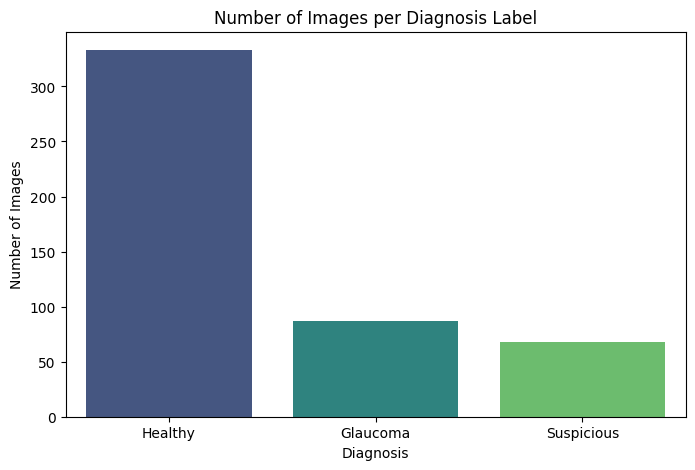

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(data=label_counts, x='Diagnosis_Label', y='Count', palette='viridis')

plt.title('Number of Images per Diagnosis Label')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Images')
plt.show()

In [33]:
idx_to_label = {0: 'Healthy', 1: 'Glaucoma', 2: 'Suspicious'}

def show_samples_per_class(df, image_dir, samples_per_class=3):
    plt.figure(figsize=(samples_per_class * 4, 12))

    for class_id in range(3):
        class_samples = df[df['Diagnosis'] == class_id]
        sampled = class_samples.sample(n=samples_per_class, random_state=42)
        
        for i, (_, row) in enumerate(sampled.iterrows()):
            img_path = os.path.join(image_dir, row['filename'])
            img = Image.open(img_path).convert("RGB")
            
            plt_idx = class_id * samples_per_class + i + 1
            plt.subplot(3, samples_per_class, plt_idx)
            plt.imshow(img)
            plt.title(f"{idx_to_label[class_id]}\n{row['filename']}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

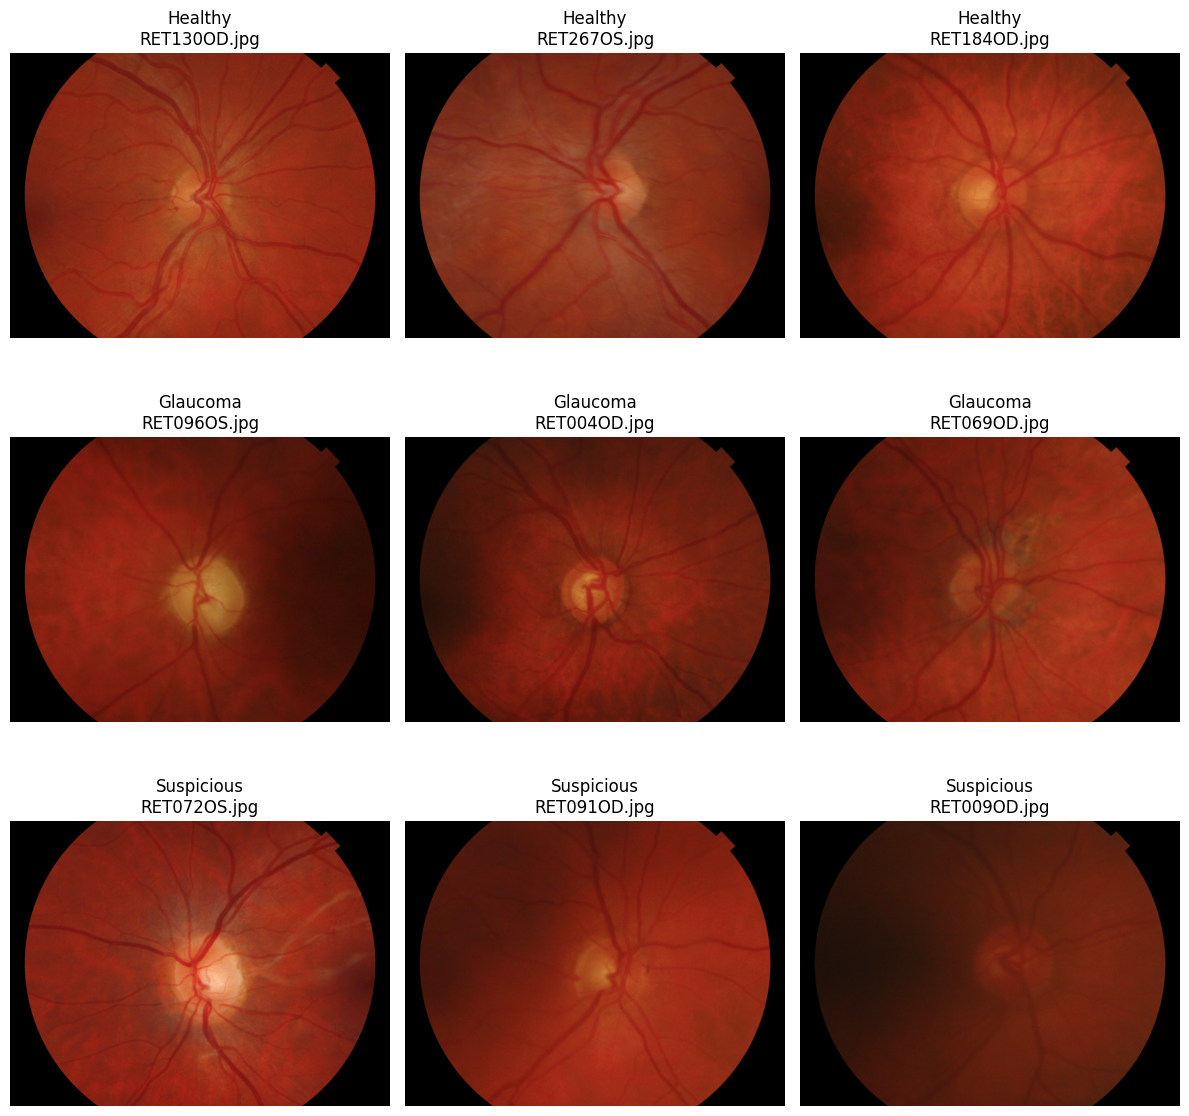

In [34]:
show_samples_per_class(labels_df, image_dir)

In [35]:
class PapilaRetinalDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get filename and label
        filename = self.dataframe.loc[idx, 'filename']
        label = int(self.dataframe.loc[idx, 'Diagnosis'])

        # Load image
        img_path = os.path.join(self.image_dir, filename)
        img = Image.open(img_path).convert("RGB")

        # Apply transform if any
        if self.transform:
            img = self.transform(img)

        return img, label

In [36]:
transform_train = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

transform_val = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [37]:
df_filtered = labels_df[labels_df['Diagnosis'] != 2].copy()
print(df_filtered['Diagnosis_Label'].value_counts())

Diagnosis_Label
Healthy     333
Glaucoma     87
Name: count, dtype: int64


In [38]:
train_df, temp_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered['Diagnosis'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['Diagnosis'], random_state=42)

In [39]:
train_dataset = PapilaRetinalDataset(train_df, image_dir, transform=transform_train)
val_dataset = PapilaRetinalDataset(val_df, image_dir, transform=transform_val)
test_dataset = PapilaRetinalDataset(test_df, image_dir, transform=transform_val)

In [40]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [41]:
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 336
Number of validation samples: 42
Number of test samples: 42


In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
all_labels = train_df['Diagnosis'].values
class_weights_np = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

In [43]:
def get_resnet50_model():
    model = resnet50(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)
    return model

In [44]:
def get_vgg16_model():
    model = vgg16(pretrained=True)
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, 2)
    return model

In [45]:
def get_mobilenet_v2_model():
    model = mobilenet_v2(pretrained=True)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 2)
    return model

In [46]:
def get_densenet121_model():
    model = densenet121(pretrained=True)
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, 2)
    return model

In [47]:
def train_model(model, train_loader, val_loader, model_name, class_weights, learning_rate=1e-4, epochs=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3, verbose=True)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    patience = 5
    wait = 0
    start_time = time.time()

    # History tracking lists
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    val_aucs = [] # <-- NEW: List to store AUC scores

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 40)

        # --- Training phase (remains the same) ---
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_bar = tqdm(train_loader, desc="Training", leave=False)
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
            train_bar.set_postfix(loss=loss.item())

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # --- Validation phase (with AUC calculation) ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        # <-- NEW: Lists to collect predictions and labels for AUC
        all_labels_list = []
        all_preds_probs = []

        val_bar = tqdm(val_loader, desc="Validating", leave=False)
        with torch.no_grad():
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                # <-- NEW: Collect data for AUC
                # Apply softmax to get probabilities
                probabilities = F.softmax(outputs, dim=1)
                # Get the probability of the positive class (Glaucoma, class 1)
                positive_class_probs = probabilities[:, 1]
                
                all_preds_probs.extend(positive_class_probs.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        
        # <-- NEW: Calculate AUC score for the epoch
        val_auc = roc_auc_score(all_labels_list, all_preds_probs)
        
        scheduler.step(val_loss)

        # Append all stats to history
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        val_aucs.append(val_auc) # <-- NEW: Save AUC score

        # <-- UPDATED: Print statement includes AUC
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

        # --- Early stopping and model saving (remains the same) ---
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            wait = 0
            torch.save(model.state_dict(), f"{model_name}.pth")
            print("✅ Saved new best model!")
        else:
            wait += 1
            print(f"⏳ No improvement... (wait {wait}/{patience})")
            if wait >= patience:
                print("Early stopping triggered!")
                break

    total_time = time.time() - start_time
    print(f"🕒 Total training time for {model_name}: {total_time:.2f} seconds")

    model.load_state_dict(best_model_wts)
    
    # <-- UPDATED: Return dictionary includes AUCs
    return model, {
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accuracies': train_accuracies, 'val_accuracies': val_accuracies,
        'val_aucs': val_aucs
    }

In [48]:
resnet_model = get_resnet50_model()
trained_resnet, resnet_stats = train_model(resnet_model, train_loader, val_loader, model_name="resnet50", class_weights=class_weights)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50
----------------------------------------


Train Loss: 0.6392 | Train Acc: 0.6399 | Val Loss: 0.6323 | Val Acc: 0.7857 | Val AUC: 0.7811 | LR: 0.000100
✅ Saved new best model!

Epoch 2/50
----------------------------------------


Train Loss: 0.5519 | Train Acc: 0.6845 | Val Loss: 0.6332 | Val Acc: 0.8095 | Val AUC: 0.7744 | LR: 0.000100
⏳ No improvement... (wait 1/5)

Epoch 3/50
----------------------------------------


Train Loss: 0.5098 | Train Acc: 0.7649 | Val Loss: 0.6212 | Val Acc: 0.7857 | Val AUC: 0.7407 | LR: 0.000100
✅ Saved new best model!

Epoch 4/50
----------------------------------------


...

Train Loss: 0.3039 | Train Acc: 0.8869 | Val Loss: 0.4205 | Val Acc: 0.8571 | Val AUC: 0.9327 | LR: 0.000100
⏳ No improvement... (wait 1/5)

Epoch 10/50
----------------------------------------


Train Loss: 0.3377 | Train Acc: 0.8810 | Val Loss: 0.5871 | Val Acc: 0.8571 | Val AUC: 0.9158 | LR: 0.000100
⏳ No improvement... (wait 2/5)

Epoch 11/50
----------------------------------------


Train Loss: 0.2199 | Train Acc: 0.9107 | Val Loss: 0.4296 | Val Acc: 0.8810 | Val AUC: 0.9428 | LR: 0.000100
⏳ No improvement... (wait 3/5)

Epoch 12/50
----------------------------------------


Train Loss: 0.2071 | Train Acc: 0.9048 | Val Loss: 0.4326 | Val Acc: 0.7857 | Val AUC: 0.9192 | LR: 0.000030
⏳ No improvement... (wait 4/5)

Epoch 13/50
----------------------------------------


Train Loss: 0.1959 | Train Acc: 0.9167 | Val Loss: 0.4353 | Val Acc: 0.8095 | Val AUC: 0.9125 | LR: 0.000030
⏳ No improvement... (wait 5/5)
Early stopping triggered!
🕒 Total training time for resnet50: 335.32 seconds


In [49]:
vgg_model = get_vgg16_model()
trained_vgg, vgg_stats = train_model(vgg_model,train_loader,val_loader,model_name="vgg16", class_weights=class_weights)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 234MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch 1/50
----------------------------------------


Train Loss: 0.7575 | Train Acc: 0.5714 | Val Loss: 0.6905 | Val Acc: 0.2143 | Val AUC: 0.7037 | LR: 0.000100
✅ Saved new best model!

Epoch 2/50
----------------------------------------


Train Loss: 0.7143 | Train Acc: 0.4762 | Val Loss: 0.6565 | Val Acc: 0.7857 | Val AUC: 0.7879 | LR: 0.000100
✅ Saved new best model!

Epoch 3/50
----------------------------------------


Train Loss: 0.6791 | Train Acc: 0.7798 | Val Loss: 0.6681 | Val Acc: 0.7857 | Val AUC: 0.8081 | LR: 0.000100
⏳ No improvement... (wait 1/5)

Epoch 4/50
----------------------------------------


...

Train Loss: 0.6063 | Train Acc: 0.6875 | Val Loss: 0.5908 | Val Acc: 0.8095 | Val AUC: 0.7778 | LR: 0.000100
⏳ No improvement... (wait 1/5)

Epoch 11/50
----------------------------------------


Train Loss: 0.6158 | Train Acc: 0.7173 | Val Loss: 0.6026 | Val Acc: 0.7857 | Val AUC: 0.7643 | LR: 0.000100
⏳ No improvement... (wait 2/5)

Epoch 12/50
----------------------------------------


Train Loss: 0.5951 | Train Acc: 0.6696 | Val Loss: 0.6732 | Val Acc: 0.7857 | Val AUC: 0.7677 | LR: 0.000100
⏳ No improvement... (wait 3/5)

Epoch 13/50
----------------------------------------


Train Loss: 0.5991 | Train Acc: 0.6815 | Val Loss: 0.6726 | Val Acc: 0.8095 | Val AUC: 0.7306 | LR: 0.000030
⏳ No improvement... (wait 4/5)

Epoch 14/50
----------------------------------------


Train Loss: 0.5411 | Train Acc: 0.7738 | Val Loss: 0.6116 | Val Acc: 0.8333 | Val AUC: 0.7273 | LR: 0.000030
⏳ No improvement... (wait 5/5)
Early stopping triggered!
🕒 Total training time for vgg16: 387.01 seconds


In [50]:
mobilenet_model = get_mobilenet_v2_model()
trained_mobilenet, mobilenet_stats = train_model(model=mobilenet_model,train_loader=train_loader,val_loader=val_loader,model_name="mobilenet_v2", class_weights=class_weights)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 158MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.



Epoch 1/50
----------------------------------------


Train Loss: 0.6276 | Train Acc: 0.6637 | Val Loss: 0.6515 | Val Acc: 0.7619 | Val AUC: 0.7744 | LR: 0.000100
✅ Saved new best model!

Epoch 2/50
----------------------------------------


Train Loss: 0.5373 | Train Acc: 0.6905 | Val Loss: 0.6395 | Val Acc: 0.8095 | Val AUC: 0.8182 | LR: 0.000100
✅ Saved new best model!

Epoch 3/50
----------------------------------------


Train Loss: 0.5482 | Train Acc: 0.7143 | Val Loss: 0.5676 | Val Acc: 0.8571 | Val AUC: 0.8148 | LR: 0.000100
✅ Saved new best model!

Epoch 4/50
----------------------------------------


...

Train Loss: 0.4372 | Train Acc: 0.8244 | Val Loss: 0.6410 | Val Acc: 0.8333 | Val AUC: 0.8552 | LR: 0.000100
⏳ No improvement... (wait 1/5)

Epoch 8/50
----------------------------------------


Train Loss: 0.3511 | Train Acc: 0.8065 | Val Loss: 0.6459 | Val Acc: 0.8333 | Val AUC: 0.8451 | LR: 0.000100
⏳ No improvement... (wait 2/5)

Epoch 9/50
----------------------------------------


Train Loss: 0.3484 | Train Acc: 0.8304 | Val Loss: 0.6731 | Val Acc: 0.8095 | Val AUC: 0.8519 | LR: 0.000100
⏳ No improvement... (wait 3/5)

Epoch 10/50
----------------------------------------


Train Loss: 0.3306 | Train Acc: 0.8333 | Val Loss: 0.5393 | Val Acc: 0.8333 | Val AUC: 0.8754 | LR: 0.000030
⏳ No improvement... (wait 4/5)

Epoch 11/50
----------------------------------------


Train Loss: 0.3058 | Train Acc: 0.8929 | Val Loss: 0.5831 | Val Acc: 0.8333 | Val AUC: 0.8889 | LR: 0.000030
⏳ No improvement... (wait 5/5)
Early stopping triggered!
🕒 Total training time for mobilenet_v2: 269.44 seconds


In [51]:
densenet_model = get_densenet121_model()
trained_densenet, densenet_stats = train_model(model=densenet_model,train_loader=train_loader,val_loader=val_loader,model_name="densenet121", class_weights=class_weights)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 195MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  wa


Epoch 1/50
----------------------------------------


Train Loss: 0.6506 | Train Acc: 0.6339 | Val Loss: 0.5958 | Val Acc: 0.7857 | Val AUC: 0.8620 | LR: 0.000100
✅ Saved new best model!

Epoch 2/50
----------------------------------------


Train Loss: 0.5724 | Train Acc: 0.6875 | Val Loss: 0.5754 | Val Acc: 0.7857 | Val AUC: 0.8485 | LR: 0.000100
✅ Saved new best model!

Epoch 3/50
----------------------------------------


Train Loss: 0.4554 | Train Acc: 0.7798 | Val Loss: 0.4757 | Val Acc: 0.8095 | Val AUC: 0.8620 | LR: 0.000100
✅ Saved new best model!

Epoch 4/50
----------------------------------------


...

Train Loss: 0.1282 | Train Acc: 0.9464 | Val Loss: 0.4060 | Val Acc: 0.8571 | Val AUC: 0.9293 | LR: 0.000030
⏳ No improvement... (wait 1/5)

Epoch 14/50
----------------------------------------


Train Loss: 0.1092 | Train Acc: 0.9821 | Val Loss: 0.4609 | Val Acc: 0.8571 | Val AUC: 0.9360 | LR: 0.000030
⏳ No improvement... (wait 2/5)

Epoch 15/50
----------------------------------------


Train Loss: 0.0993 | Train Acc: 0.9702 | Val Loss: 0.4545 | Val Acc: 0.8571 | Val AUC: 0.9394 | LR: 0.000009
⏳ No improvement... (wait 3/5)

Epoch 16/50
----------------------------------------


Train Loss: 0.1363 | Train Acc: 0.9583 | Val Loss: 0.4070 | Val Acc: 0.8571 | Val AUC: 0.9428 | LR: 0.000009
⏳ No improvement... (wait 4/5)

Epoch 17/50
----------------------------------------


Train Loss: 0.0969 | Train Acc: 0.9673 | Val Loss: 0.3931 | Val Acc: 0.8571 | Val AUC: 0.9428 | LR: 0.000009
⏳ No improvement... (wait 5/5)
Early stopping triggered!
🕒 Total training time for densenet121: 435.76 seconds


In [52]:
resnet_model = get_resnet50_model()
resnet_model.load_state_dict(torch.load("resnet50.pth"))

vgg_model = get_vgg16_model()
vgg_model.load_state_dict(torch.load("vgg16.pth"))

mobilenet_model = get_mobilenet_v2_model()
mobilenet_model.load_state_dict(torch.load("mobilenet_v2.pth"))

densenet_model = get_densenet121_model()
densenet_model.load_state_dict(torch.load("densenet121.pth"))

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
 

<All keys matched successfully>

In [53]:
def evaluate_model(model, test_loader):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []  # For AUC

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())           # Predicted class
            all_labels.extend(labels.cpu().numpy())         # True class
            all_probs.extend(probs[:, 1].cpu().numpy())     # Prob of class 1

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)  # <-- use probs here!
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return accuracy, f1, auc, precision, recall, cm

In [54]:
resnet_acc, resnet_f1, resnet_auc, resnet_precision, resnet_recall, resnet_cm = evaluate_model(resnet_model, test_loader)
vgg_acc, vgg_f1, vgg_auc, vgg_precision, vgg_recall, vgg_cm = evaluate_model(vgg_model, test_loader)
mobilenet_acc, mobilenet_f1, mobilenet_auc, mobilenet_precision, mobilenet_recall, mobilenet_cm = evaluate_model(mobilenet_model, test_loader)
densenet_acc, densenet_f1, densenet_auc, densenet_precision, densenet_recall, densenet_cm = evaluate_model(densenet_model, test_loader)

In [55]:
print("ResNet50 - Accuracy: {:.4f}, F1-Score: {:.4f}, ROC AUC: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(resnet_acc, resnet_f1, resnet_auc, resnet_precision, resnet_recall))
print("Vgg16 - Accuracy: {:.4f}, F1-Score: {:.4f}, ROC AUC: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(vgg_acc, vgg_f1, vgg_auc, vgg_precision, vgg_recall))
print("Mobilenet - Accuracy: {:.4f}, F1-Score: {:.4f}, ROC AUC: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(mobilenet_acc, mobilenet_f1, mobilenet_auc, mobilenet_precision, mobilenet_recall))
print("Densenet - Accuracy: {:.4f}, F1-Score: {:.4f}, ROC AUC: {:.4f}, Precision: {:.4f}, Recall: {:.4f}".format(densenet_acc, densenet_f1, densenet_auc, densenet_precision, densenet_recall))

ResNet50 - Accuracy: 0.7857, F1-Score: 0.6400, ROC AUC: 0.9522, Precision: 0.4706, Recall: 1.0000
Vgg16 - Accuracy: 0.5952, F1-Score: 0.4516, ROC AUC: 0.7537, Precision: 0.3043, Recall: 0.8750
Mobilenet - Accuracy: 0.8571, F1-Score: 0.6667, ROC AUC: 0.8676, Precision: 0.6000, Recall: 0.7500
Densenet - Accuracy: 0.8810, F1-Score: 0.7368, ROC AUC: 0.9632, Precision: 0.6364, Recall: 0.8750
